In [3]:
import os
import random

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

In [7]:
IMAGE_DIR = "../images/train"
CSV_PATH = "../data/raw/train.csv"

In [8]:
df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
df.head()

CSV shape: (16209, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [9]:
image_files = sorted(os.listdir(IMAGE_DIR))

print("Number of images:", len(image_files))
print("First 5 image files:", image_files[:5])

Number of images: 16201
First 5 image files: ['0.png', '1.png', '10.png', '100.png', '1000.png']


In [10]:
def image_exists_for_index(idx):
    return os.path.exists(os.path.join(IMAGE_DIR, f"{idx}.png"))

missing_images = [i for i in range(len(df)) if not image_exists_for_index(i)]

print("Missing images:", len(missing_images))
missing_images[:10]


Missing images: 8


[932, 1801, 2443, 11015, 12714, 13762, 14885, 15473]

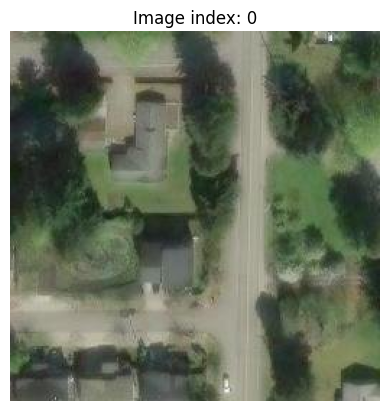

In [11]:
idx = 0
img_path = os.path.join(IMAGE_DIR, f"{idx}.png")

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Image index: {idx}")
plt.show()


In [12]:
print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (256, 256)
Image mode: RGB


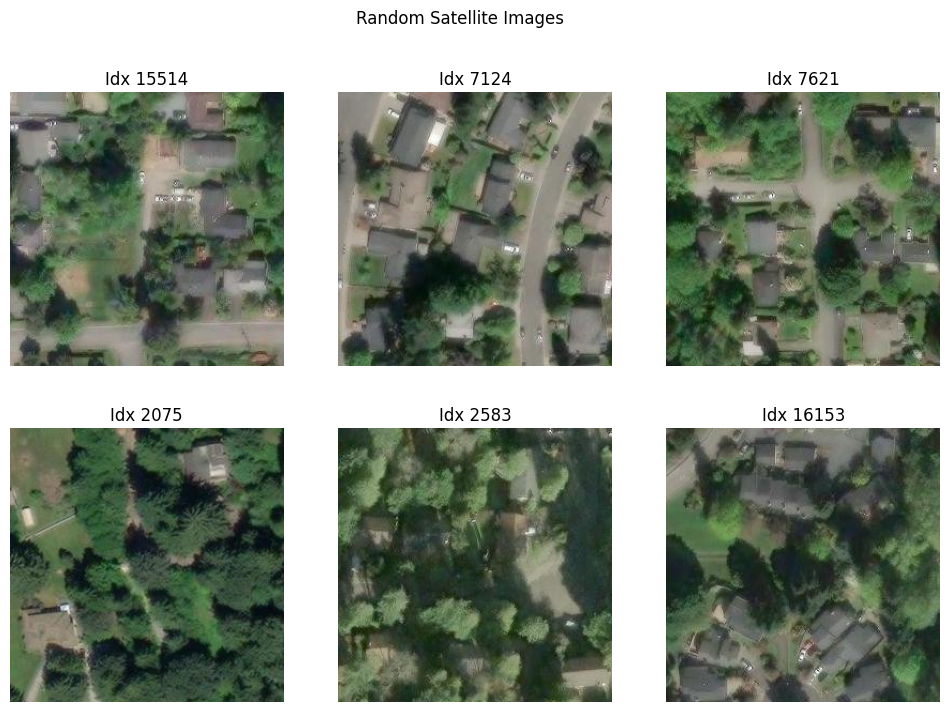

In [13]:
random_indices = random.sample(range(len(df)), 6)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(random_indices):
    img = Image.open(os.path.join(IMAGE_DIR, f"{idx}.png"))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Idx {idx}")
    plt.axis("off")

plt.suptitle("Random Satellite Images")
plt.show()


In [14]:
sample_idx = random.choice(range(len(df)))
lat, lon = df.loc[sample_idx, ["lat", "long"]]

df["distance"] = np.sqrt(
    (df["lat"] - lat)**2 + (df["long"] - lon)**2
)

nearest = df.nsmallest(4, "distance").index.tolist()


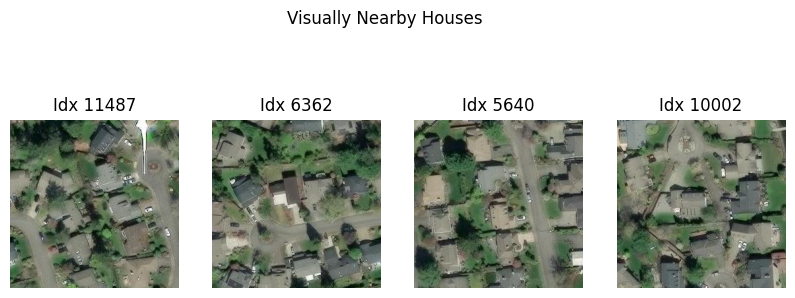

In [15]:
plt.figure(figsize=(10, 4))

for i, idx in enumerate(nearest):
    img = Image.open(os.path.join(IMAGE_DIR, f"{idx}.png"))
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Idx {idx}")
    plt.axis("off")

plt.suptitle("Visually Nearby Houses")
plt.show()


In [16]:
img_array = np.array(img)

print("Pixel min:", img_array.min())
print("Pixel max:", img_array.max())
print("Mean pixel value:", img_array.mean())


Pixel min: 0
Pixel max: 255
Mean pixel value: 104.05947367350261
